# The goal of this notebook is to test the drift mechanism on changes in singal $\mu$

### Test design
**Data** 
use a single image from the dataset. HYPSO-1_HSI_20230819T092813Z\
*Trainingdata* = first 10 rows (10*684=6840 pixels)\
*Testdata* = remaining rows ((956-10)*684=647,064 pixels), at every row, a signaldrift is small but notable added to the pixels

**Models**
ALL models used q=5 dimensions for a fair comparison, and they are:
- PCA 
- Static MFA trained 
- OMFA without sEM
- OAMFA

**Test**
Transpose the image and stream one line at a time. In this manner the x-axis allso represents time.\
For each line: 
1) Project each pixel to the latent space using all the models. 
2) Calculate the RMSE and SAM from the latent variable to the real variable
3) Measure component bloat ($K$), e.g. how many new components are spawned.
3) Perform the assingment 

**Signal Drift**
To simulate a signaldrift, ...

**Plot**
- Figure A:\
Performance & Bloat (Line Graphs)\
Top Row: RGB image with the initialization boundary (dotted line) and an arrow indicating the direction of the temporal drift.\
Middle Row: Average Assignment SAM (y-axis) vs. Time/Row (x-axis). (Show OAMFA staying flat, Static MFA rising).\
Bottom Row: Total Components $K$ (y-axis) vs. Time/Row (x-axis). (Show OMFA rocketing upwards, OAMFA staying flat).\

- Figure B:\
Spatial Error (The Heatmaps)\ 
Grid of 4 Heatmaps: One for each model (PCA, Static MFA, OMFA, OAMFA).\ 
The heat represents the Assignment SAM (or RMSE) for every pixel.\
Static MFA will be dark blue at the top (low error) and turn bright red at the bottom (high error due to drift).\
OAMFA will remain dark blue the entire way down.\

- Figure C:\
Parameter Plot:\
Show how the average value of OAMFA's $\mathbf{\mu}$ (for the initial clusters) shifts over time, explicitly proving the model is tracking the drift, while $\Psi$ stays mostly flat (contrasting perfectly with Case 3).

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from utils import get_rgb, calculate_sam, reconstruct_mfa
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
import matplotlib.patches as patches

parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from otfp import MFA_OTFP
from hypso import Hypso


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L2_NORMALIZATION = True  # Set to True to enable L2 normalization, False to disable

Loading baseline hypercube from ../data/signal_drift/bodo_2023-08-19T09-28-13Z-l1b.nc...
Successfully loaded | Shape: (956, 684, 120)
Applying progressive atmospheric absorption to 906 test rows...
--- Split & Drift Summary ---
Training Rows:  50 -> Shape: (50, 684, 120)
Testing Rows:   906 -> Shape: (906, 684, 120)
Drift injected! Max attenuation: 30.0% at band 60.


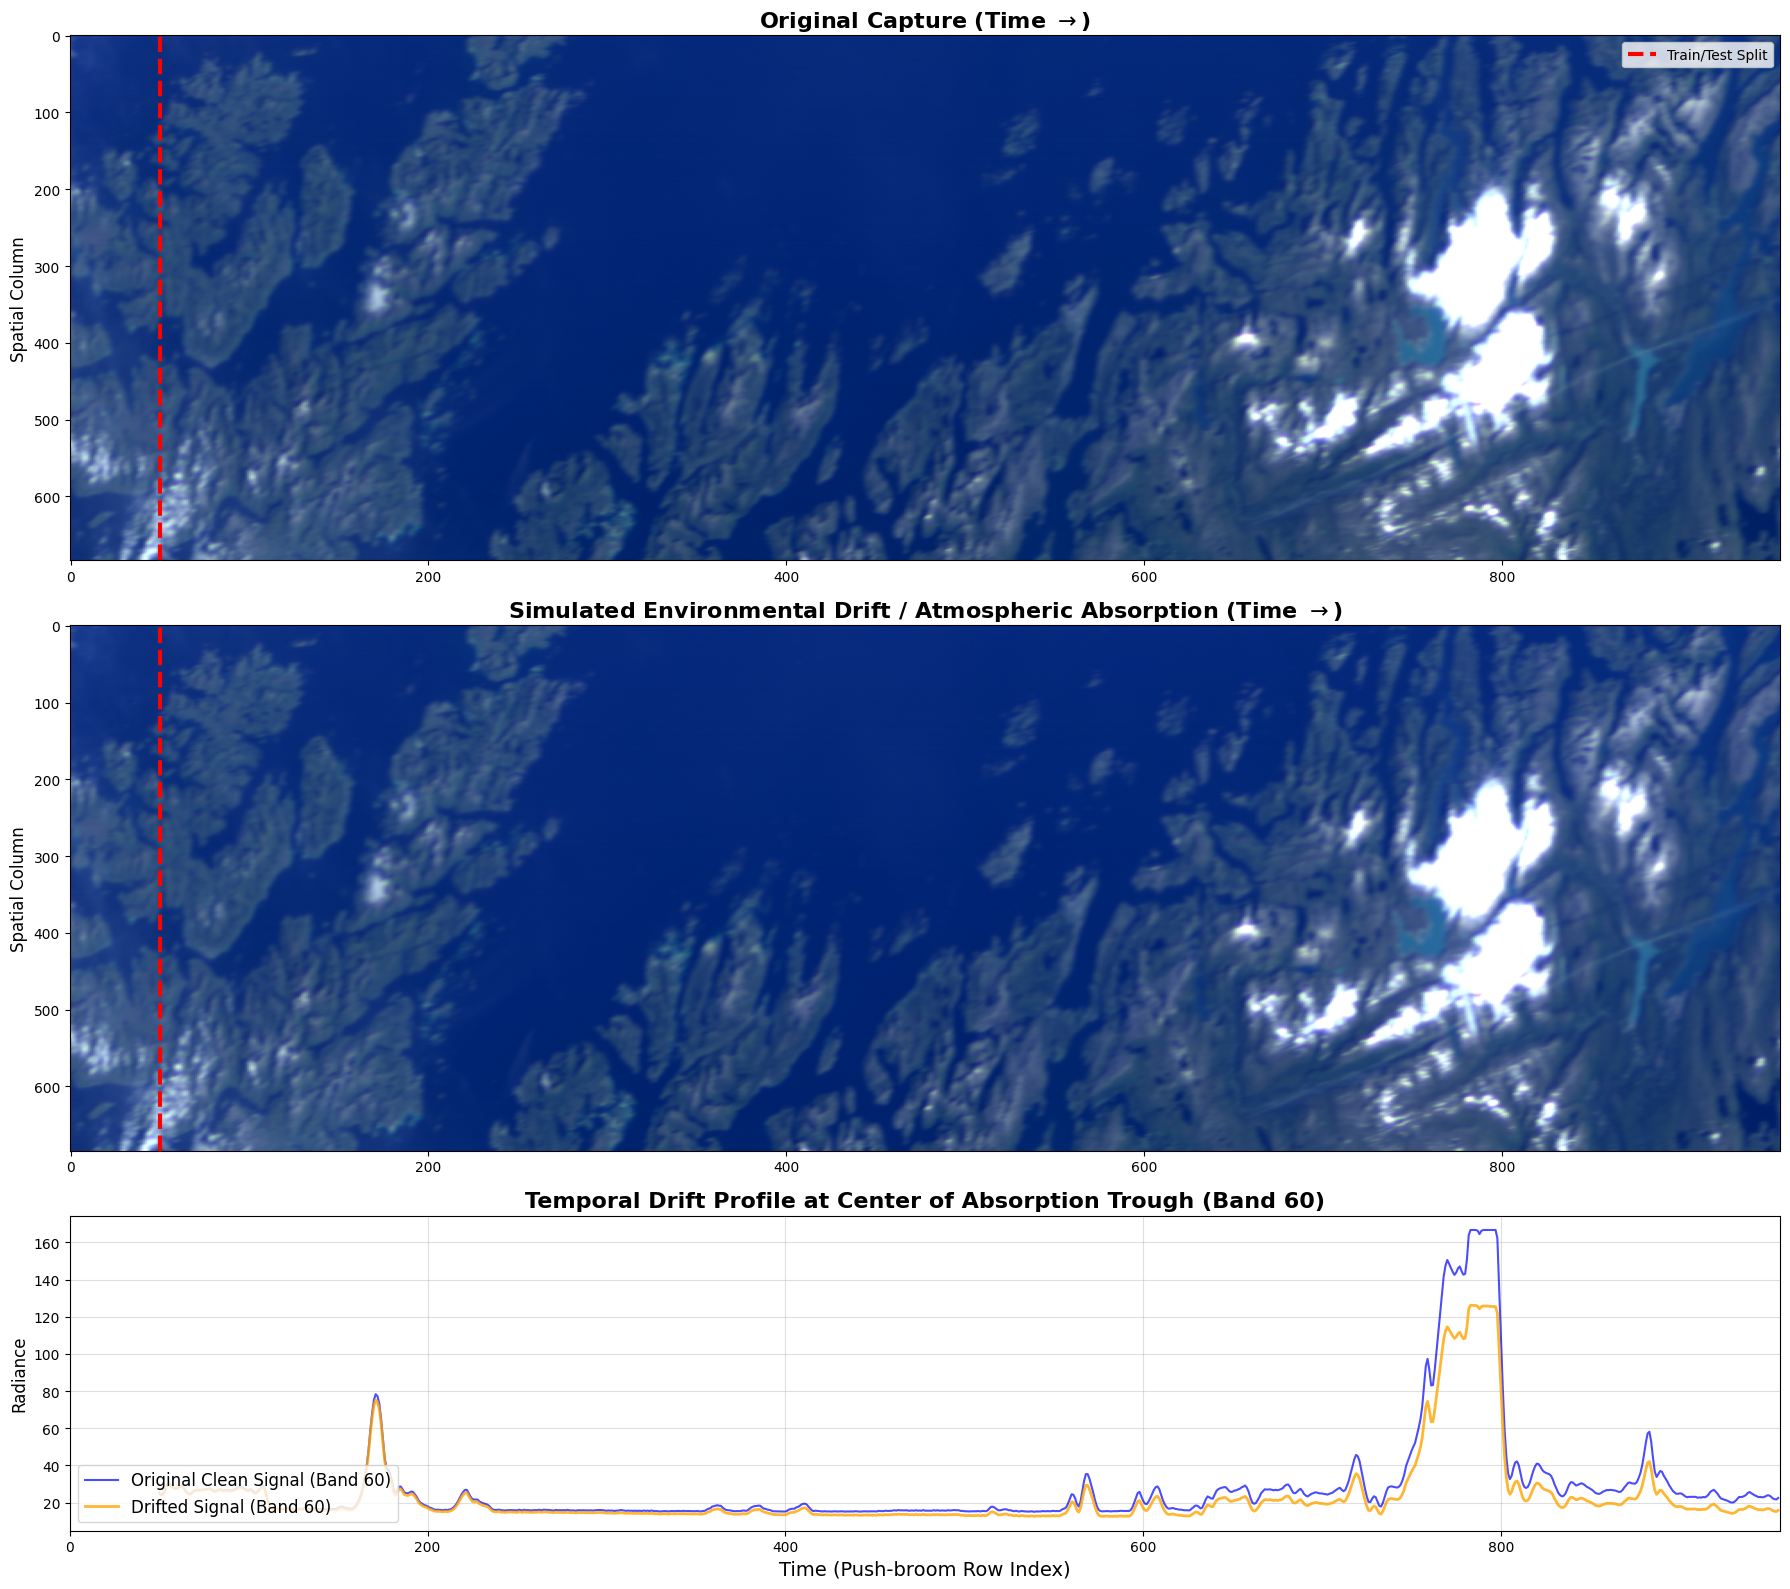

In [2]:
DATA_PATH = "../data/signal_drift/bodo_2023-08-19T09-28-13Z-l1b.nc" #Works well
MAX_ILLUMINATION_INCREASE = 3

# --- 1. Load Data ---
print(f"Loading baseline hypercube from {DATA_PATH}...")
try:
    satobj = Hypso(DATA_PATH)
    cube = getattr(satobj, "l1b_cube", None)
    if cube is None:
        raise ValueError("Missing 'l1b_cube' data.")
    
    img_full = cube.values.astype(np.float32)
    print(f"Successfully loaded | Shape: {img_full.shape}")
except Exception as e:
    print(f"FATAL: Error processing {DATA_PATH}: {e}")
    sys.exit()

H, W, D = img_full.shape
N_TRAIN_ROWS = 50
N_TEST_ROWS = H - N_TRAIN_ROWS

# Split the data
img_train = img_full[:N_TRAIN_ROWS, :, :].copy()
img_test = img_full[N_TRAIN_ROWS:, :, :].copy()

# 2. SIMULATE ENVIRONMENTAL SIGNAL DRIFT (Atmospheric Absorption)
print(f"Applying progressive atmospheric absorption to {N_TEST_ROWS} test rows...")

# Parameters for the absorption trough
A_max = 0.30       # Maximum attenuation (30% signal loss at the final row)
b_c = 60           # Center band of the absorption trough (e.g., an O2/H2O absorption line)
sigma_drift = 5.0  # Spectral width of the absorption trough

# Create the drift coefficient vector 'd' (Gaussian shape)
bands = np.arange(D)
d_vector = A_max * np.exp(-0.5 * ((bands - b_c) / sigma_drift)**2)

# Progressively apply the multiplicative drift to the test set
# t represents the time/row index
for t in range(N_TEST_ROWS):
    # Calculate the current attenuation multiplier for this row
    # As t approaches N_TEST_ROWS, the multiplier approaches (1 - d_vector)
    time_ratio = t / (N_TEST_ROWS - 1)
    attenuation_multiplier = 1.0 - (d_vector * time_ratio)
    
    # Apply multiplicatively across all pixels in this row
    # img_test[t] shape is (W, D). Broadcasting (W, D) * (D,) applies the trough correctly!
    img_test[t, :, :] = img_test[t, :, :] * attenuation_multiplier

print(f"--- Split & Drift Summary ---")
print(f"Training Rows:  {N_TRAIN_ROWS} -> Shape: {img_train.shape}")
print(f"Testing Rows:   {N_TEST_ROWS} -> Shape: {img_test.shape}")
print(f"Drift injected! Max attenuation: {A_max*100}% at band {b_c}.")

# Recombine if your streaming loop expects the full image
# (Alternatively, you can just pass img_train for init and stream img_test)
img_drifted_full = np.vstack((img_train, img_test))

# 5. Plotting the Experimental Setup (TRANSPOSED & SCALED)
# We use gridspec_kw to make the images taller (ratio 1) and the line plot shorter (ratio 0.6)
fig, axes = plt.subplots(3, 1, figsize=(18, 16), gridspec_kw={'height_ratios': [1, 1, 0.6]}) 

# Helper to transpose RGB for plotting (Time on X-axis, Spatial Column on Y-axis)
# (Assuming get_rgb is defined in your environment)
def transpose_for_time_x(hsi_cube):
    return np.transpose(get_rgb(hsi_cube), (1, 0, 2))

# 5a. Original Image
axes[0].imshow(transpose_for_time_x(img_full), aspect='auto')
axes[0].set_title("Original Capture (Time $\\rightarrow$)", fontsize=16, fontweight='bold')
axes[0].axvline(x=N_TRAIN_ROWS, color='red', linestyle='--', linewidth=3, label="Train/Test Split")
axes[0].set_ylabel("Spatial Column", fontsize=12)
axes[0].legend(loc="upper right")

# 5b. Degraded Image
# FIX 1: Use 'img_drifted_full' instead of 'img_full_shifted'
axes[1].imshow(transpose_for_time_x(img_drifted_full), aspect='auto')
axes[1].set_title("Simulated Environmental Drift / Atmospheric Absorption (Time $\\rightarrow$)", fontsize=16, fontweight='bold')
axes[1].axvline(x=N_TRAIN_ROWS, color='red', linestyle='--', linewidth=3)
axes[1].set_ylabel("Spatial Column", fontsize=12)

# 5c. Spectral Drift Proof
target_col = W // 2
target_band = b_c # Band 60 (the center of our simulated absorption trough)

# FIX 2: Extract the signal intensity for the specific band over time, rather than the mean spectrum
signal_clean = img_full[N_TRAIN_ROWS:, target_col, target_band]
signal_drifted = img_drifted_full[N_TRAIN_ROWS:, target_col, target_band]

# FIX 3: Use N_TEST_ROWS instead of the undefined total_test_rows
x_time = np.arange(N_TRAIN_ROWS, N_TRAIN_ROWS + N_TEST_ROWS)

# FIX 4: Correct the labels (clean is blue, drifted is orange)
axes[2].plot(x_time, signal_clean, label=f"Original Clean Signal (Band {target_band})", color='blue', alpha=0.7)
axes[2].plot(x_time, signal_drifted, label=f"Drifted Signal (Band {target_band})", color='orange', alpha=0.8, linewidth=2)

axes[2].set_title(f"Temporal Drift Profile at Center of Absorption Trough (Band {target_band})", fontsize=16, fontweight='bold')
axes[2].set_xlabel("Time (Push-broom Row Index)", fontsize=14)
axes[2].set_ylabel("Radiance", fontsize=12)
axes[2].legend(loc="lower left", fontsize=12)
axes[2].grid(True, alpha=0.4)
axes[2].set_xlim(0, H) # Show the entire timeline from t=0 to t=H

plt.tight_layout()
plt.show()

# Clean up memory


#### Plotting spectral band for forest pixels at t = 0, t = T/2, and t = T

--- GENERATING SPATIAL-SPECTRAL INSPECTION PLOT ---


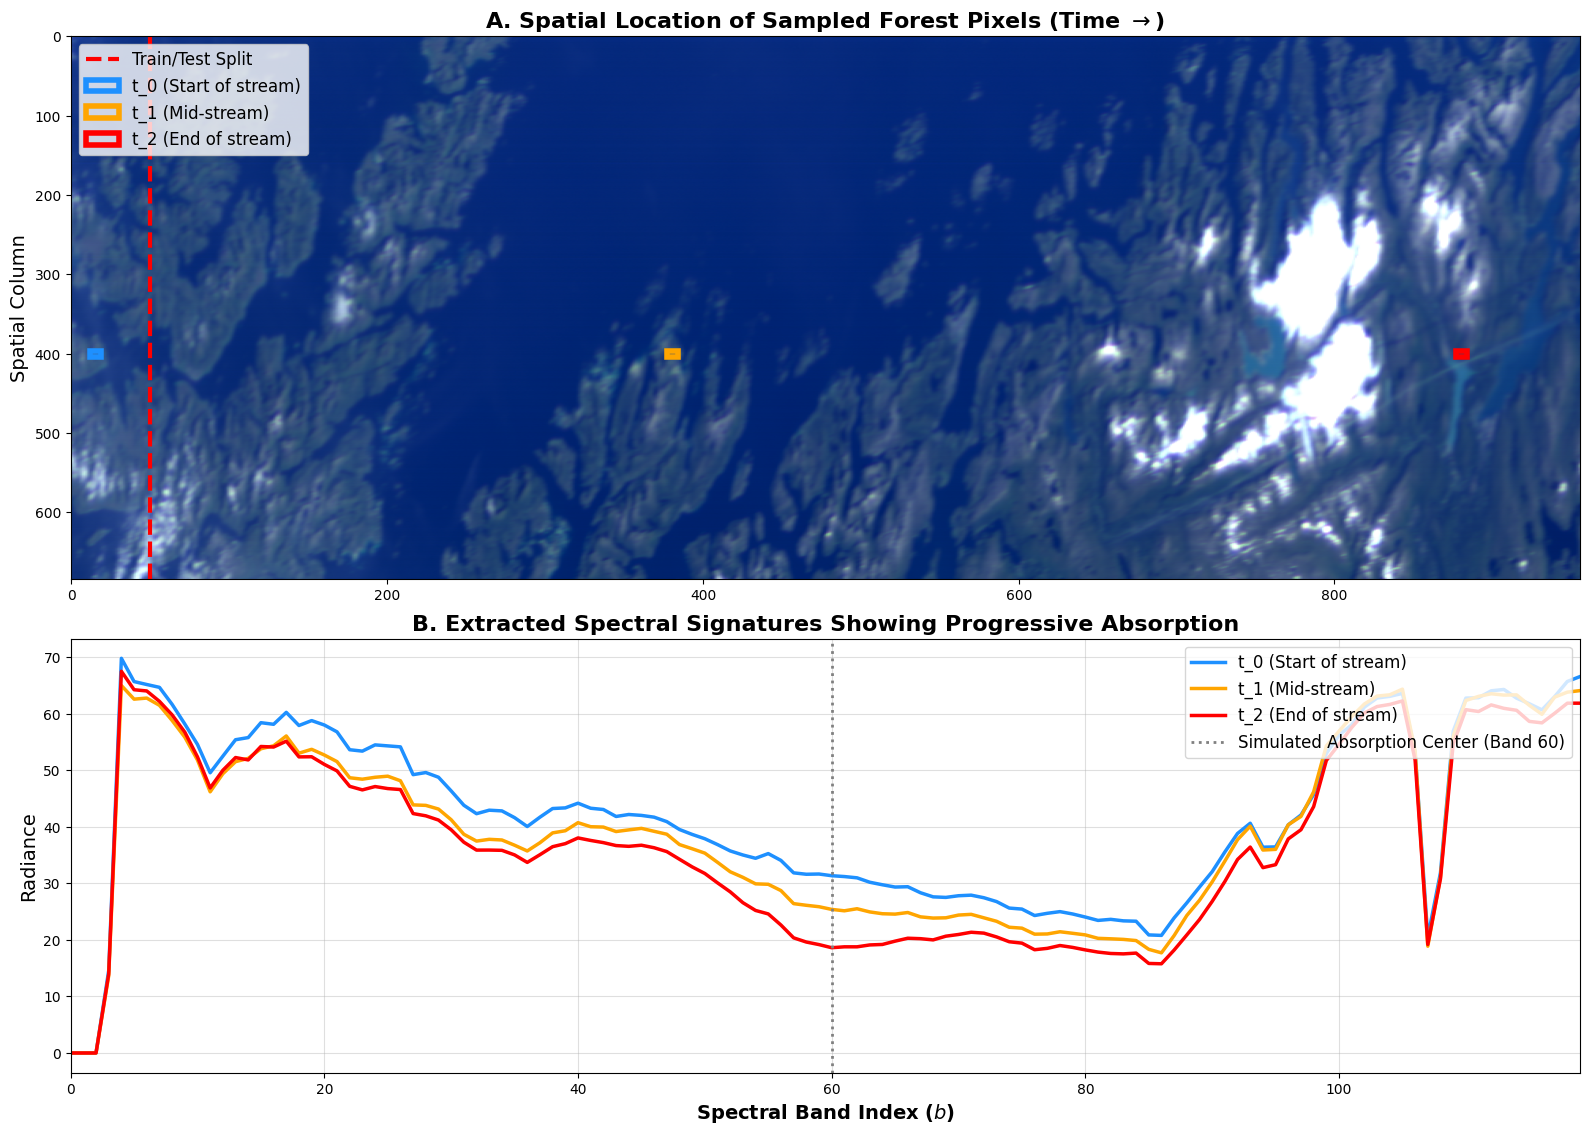

In [3]:

print("--- GENERATING SPATIAL-SPECTRAL INSPECTION PLOT ---")

# FIX 1: Use tuples (t, col) instead of sets to preserve exact ordering
# t is the time/row index (X-axis), col is the spatial column (Y-axis)
coordinates = {
    "t_0 (Start of stream)": (15, 400),
    "t_1 (Mid-stream)": (380, 400),
    "t_2 (End of stream)": (880, 400)
} 

# We use gridspec_kw to make the images taller (ratio 1) and the line plot shorter (ratio 0.6)
fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 0.8]}) 

# Helper to transpose RGB for plotting (Time on X-axis, Spatial Column on Y-axis)
def transpose_for_time_x(hsi_cube):
    return np.transpose(get_rgb(hsi_cube), (1, 0, 2))

# ==========================================
# PLOT A: Spatial View with Highlighted Pixels
# ==========================================
axes[0].imshow(transpose_for_time_x(img_drifted_full), aspect='auto')
axes[0].set_title("A. Spatial Location of Sampled Forest Pixels (Time $\\rightarrow$)", fontsize=16, fontweight='bold')
axes[0].axvline(x=N_TRAIN_ROWS, color='red', linestyle='--', linewidth=3, label="Train/Test Split")
axes[0].set_ylabel("Spatial Column", fontsize=14)

PATCH_SIZE = 7 # Made slightly larger so it's visible in a printed thesis
colours = ['dodgerblue', 'orange', 'red']

# Store the full spectrums
signals = {}

for idx, (key, (t, col)) in enumerate(coordinates.items()):
    color = colours[idx]
    
    # FIX 3: Rectangle coordinates are (X, Y) -> (t, col)
    # We subtract half the patch size to center the box on the pixel
    rect_source = patches.Rectangle((t - PATCH_SIZE//2, col - PATCH_SIZE//2), PATCH_SIZE, PATCH_SIZE, 
                                    linewidth=4, edgecolor=color, facecolor='none', label=key)
    axes[0].add_patch(rect_source)

    # FIX 2: Extract the full spectral shape (all bands) using ':'
    spectrum = img_drifted_full[t, col, :]
    signals[key] = spectrum

axes[0].legend(loc="upper left", fontsize=12)

# ==========================================
# PLOT B: Spectral Shape Profile
# ==========================================
# FIX 4: Create an X-axis representing the spectral bands
bands = np.arange(D) 
b_c = 60 # Center of your simulated absorption trough

axes[1].set_title("B. Extracted Spectral Signatures Showing Progressive Absorption", fontsize=16, fontweight='bold')

for idx, (key, spectrum) in enumerate(signals.items()):
    color = colours[idx]
    axes[1].plot(bands, spectrum, label=key, color=color, linewidth=2.5)

# Highlight the absorption trough center to guide the reader's eye
axes[1].axvline(x=b_c, color='gray', linestyle=':', linewidth=2, label=f"Simulated Absorption Center (Band {b_c})")

axes[1].set_xlabel("Spectral Band Index ($b$)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Radiance", fontsize=14)
axes[1].legend(loc="upper right", fontsize=12)
axes[1].grid(True, alpha=0.4)

# FIX 5: Limit the X-axis to the total number of bands (D)
axes[1].set_xlim(0, D - 1) 

plt.tight_layout()
fig.subplots_adjust(top=0.92) # Give some space at the top
plt.savefig("figures/env_signal_drift_visualization.pdf", format="pdf", bbox_inches="tight")

plt.show()

### Analyzing data distibution in the test-set

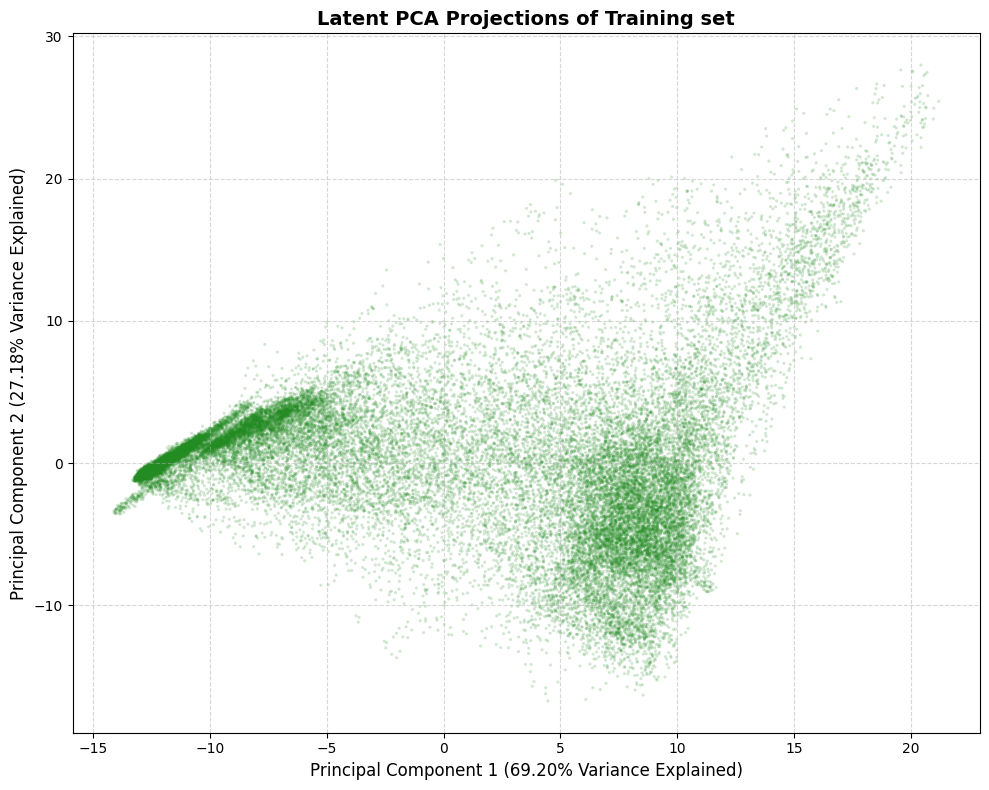

In [4]:
# Forrest-patch is fetched from the above cell

h, w, bands = img_train.shape
num_pixels = h * w

# Flatten from 3D (128, 128, B) to 2D (16384, B)
flattened_pixels = img_train.reshape(num_pixels, bands)

if L2_NORMALIZATION:
    # Optional: L2 normalize each pixel vector to focus on spectral shape rather than magnitude
    norms = np.linalg.norm(flattened_pixels, axis=1, keepdims=True) + 1e-10  # Avoid division by zero
    flattened_pixels = flattened_pixels / norms

# Optional but recommended: Standardize the features (bands)
# This ensures bands with larger numerical ranges don't dominate the PCA
scaler = StandardScaler()
scaled_pixels = scaler.fit_transform(flattened_pixels)

# --- 2. Fit the PCA model ---
# We only need 2 components for a 2D scatter plot
pca = PCA(n_components=2)
latent_projections = pca.fit_transform(scaled_pixels)

# --- 3. Extract Explained Variance ---
# Convert the ratios to percentages for the plot labels
explained_variance = pca.explained_variance_ratio_ * 100
var_pc1 = explained_variance[0]
var_pc2 = explained_variance[1]

# --- 4. Plot the Latent Projections ---
plt.figure(figsize=(10, 8))

# Using a low 'alpha' (transparency) is crucial here. 
# You are plotting 16,384 points, and they will overplot into a solid blob otherwise.
plt.scatter(
    latent_projections[:, 0], 
    latent_projections[:, 1], 
    alpha=0.2,   # Transparency to see density
    s=5,         # Small dot size
    c='forestgreen',
    edgecolors='none'
)

# Labeling with the captured variance
plt.xlabel(f'Principal Component 1 ({var_pc1:.2f}% Variance Explained)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_pc2:.2f}% Variance Explained)', fontsize=12)
plt.title('Latent PCA Projections of Training set', fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Training the models

In [5]:
# Your original code:
img_train = img_train.reshape(-1, img_train.shape[-1])  # Flatten to (num_pixels, num_bands)
img_train = torch.from_numpy(img_train).float().to(device)  # Convert to PyTorch tensor

MFA_OTFP_model=MFA_OTFP(
    n_channels=120, 
    device="cpu", 
    outlier_update_treshold=100,
    q_max=4,
    L2_normalization=L2_NORMALIZATION
)

MFA_OTFP_model.fit(img_train)

Model successfully updated! Added 2 components. Total (K) is now 2


### Streaming the different models: Static MFA, Online MFA and Adaptive Online MFA

In [6]:
import torch
import numpy as np
import copy
import time

print("--- INITIALIZING SENSOR DEGRADATION TEST ---")

# --- 1. Initialize Baseline Models ---
print("Deepcopying the pretrained MFA model into test variants...")
offline_MFA = copy.deepcopy(MFA_OTFP_model)
offline_MFA.MFA.eval()
online_MFA = copy.deepcopy(MFA_OTFP_model)
adaptive_online_MFA = copy.deepcopy(MFA_OTFP_model)

print("Fitting PCA Baseline on training data...")
img_train_flat = img_train.reshape(-1, img_train.shape[-1])
if isinstance(img_train_flat, torch.Tensor):
    img_train_tensor = img_train_flat.float()
else:
    img_train_tensor = torch.from_numpy(img_train_flat).float()

# PCA always gets raw data (it mean-centers internally)
pca_baseline = PCA(n_components=4)
pca_baseline.fit(img_train_tensor.cpu().numpy())

# --- 2. Initialize Tracking Structures ---
h, w, d = img_test.shape
device = adaptive_online_MFA.device 

# CRITICAL FIX: Dynamically check what the model expects 
print(f"MFA L2 Normalization is set to: {L2_NORMALIZATION}")

# ADDED: "K" tracking arrays for the MFA models
metrics = {
    "PCA": { "sam": []},
    "Static_MFA": { "sam": [], "K": []},
    "OMFA": { "sam": [], "K": []},
    "OAMFA": { "sam": [], "K": []}
}

oamfa_psi_history = []      
oamfa_mu_history = []       
target_band_idx = 10      

assignment_omfa_map = np.zeros((h, w))
assignment_oamfa_map = np.zeros((h, w))
mahalanobis_map = np.zeros((h, w))

baseline_k = adaptive_online_MFA.MFA.K
current_k = baseline_k
spawn_rows = []

BATCH_SIZE = 1  
print(f"Streaming hyperspectral data in batches of {BATCH_SIZE}...")
start_time = time.time()

# --- 3. The Streaming Loop ---
for t_row in range(0, h, BATCH_SIZE):
    end_row = min(t_row + BATCH_SIZE, h)
    actual_batch_size = end_row - t_row
    
    slice_data = img_test[t_row : end_row, :, :]
    batch_flat = slice_data.reshape(-1, d)
    X_batch = torch.tensor(batch_flat, dtype=torch.float32).to(device)
    
    # Create the conditional input for the raw MFA helpers
    if L2_NORMALIZATION:
        X_mfa_truth = torch.nn.functional.normalize(X_batch, p=2, dim=1)
    else:
        X_mfa_truth = X_batch # Keep it raw

    # PCA Evaluations (Always raw)
    z_pca = pca_baseline.transform(X_batch.cpu().numpy())
    X_rec_pca = torch.tensor(pca_baseline.inverse_transform(z_pca), dtype=torch.float32).to(device)
    
    # MFA Evaluations 
    assignments_omfa, _, _ = online_MFA.process_data_block(X=X_batch, stepwise_updates=False)
    assignments_oamfa, distances, _ = adaptive_online_MFA.process_data_block(X=X_batch, stepwise_updates=True)
    
    # reconstruct_mfa gets X_mfa_truth because it talks to the inner PyTorch model directly
    X_rec_static, _ = reconstruct_mfa(offline_MFA.MFA, X_mfa_truth)
    X_rec_online, _ = reconstruct_mfa(online_MFA.MFA, X_mfa_truth)
    X_rec_oamfa, _ = reconstruct_mfa(adaptive_online_MFA.MFA, X_mfa_truth)

    # 4. Spatial Un-batching & Row-by-Row Metric Logging 
    X_raw_3d = X_batch.view(actual_batch_size, w, d) 
    X_mfa_truth_3d = X_mfa_truth.view(actual_batch_size, w, d) # The correct ground truth
    
    X_rec_pca_3d = X_rec_pca.view(actual_batch_size, w, d)
    X_rec_static_3d = X_rec_static.view(actual_batch_size, w, d)
    X_rec_online_3d = X_rec_online.view(actual_batch_size, w, d)
    X_rec_oamfa_3d = X_rec_oamfa.view(actual_batch_size, w, d)

    current_psi_vector = adaptive_online_MFA.MFA.log_psi[0].detach().cpu().numpy().copy()
    current_mu_vector = adaptive_online_MFA.MFA.mu[0].detach().cpu().numpy().copy()

    # ADDED: Extract the current K values for the MFA models
    k_static = offline_MFA.MFA.K
    k_omfa = online_MFA.MFA.K
    k_oamfa = adaptive_online_MFA.MFA.K

    for b in range(actual_batch_size):
        # PCA is evaluated against the RAW 3D batch
        metrics["PCA"]["sam"].append(calculate_sam(X_raw_3d[b], X_rec_pca_3d[b]))
        
        # MFA is evaluated against the CONDITIONAL truth (Raw or L2 depending on the flag)
        metrics["Static_MFA"]["sam"].append(calculate_sam(X_mfa_truth_3d[b], X_rec_static_3d[b])) 
        metrics["OMFA"]["sam"].append(calculate_sam(X_mfa_truth_3d[b], X_rec_online_3d[b]))
        metrics["OAMFA"]["sam"].append(calculate_sam(X_mfa_truth_3d[b], X_rec_oamfa_3d[b]))
        
        # ADDED: Log the capacity metric K for each row
        metrics["Static_MFA"]["K"].append(k_static)
        metrics["OMFA"]["K"].append(k_omfa)
        metrics["OAMFA"]["K"].append(k_oamfa)

        oamfa_psi_history.append(current_psi_vector)
        oamfa_mu_history.append(current_mu_vector)
    # --- 5. Map 2D Heatmaps and Track Spawns ---
    assign_omfa_np = assignments_omfa.cpu().numpy().copy()
    assign_oamfa_np = assignments_oamfa.cpu().numpy().copy()
    dist_np = distances.cpu().numpy()
    
    assignment_omfa_map[t_row : end_row, :] = assign_omfa_np.reshape(actual_batch_size, w)
    assignment_oamfa_map[t_row : end_row, :] = assign_oamfa_np.reshape(actual_batch_size, w)
    mahalanobis_map[t_row : end_row, :] = dist_np.reshape(actual_batch_size, w)
    
    if adaptive_online_MFA.MFA.K > current_k:
        spawn_rows.append(t_row)
        current_k = adaptive_online_MFA.MFA.K

    if t_row % 100 == 0 and t_row > 0:
        print(f"Processed {t_row}/{h} rows...")

print("\n--- STREAMING COMPLETE ---")
print(f"Total processing time: {time.time() - start_time:.2f} seconds")

--- INITIALIZING SENSOR DEGRADATION TEST ---
Deepcopying the pretrained MFA model into test variants...
Fitting PCA Baseline on training data...
MFA L2 Normalization is set to: True
Streaming hyperspectral data in batches of 1...
Model successfully updated! Added 1 components. Total (K) is now 3
Processed 100/906 rows...
Processed 200/906 rows...
Model successfully updated! Added 1 components. Total (K) is now 4
Processed 300/906 rows...
Model successfully updated! Added 1 components. Total (K) is now 5
Processed 400/906 rows...
Model successfully updated! Added 1 components. Total (K) is now 6
Model successfully updated! Added 1 components. Total (K) is now 7
Processed 500/906 rows...
Model successfully updated! Added 1 components. Total (K) is now 8
Model successfully updated! Added 1 components. Total (K) is now 9
Model successfully updated! Added 1 components. Total (K) is now 10
Processed 600/906 rows...
Processed 700/906 rows...
Model successfully updated! Added 1 components. Tot

### Plotting 

--- GENERATING FIGURE A: PERFORMANCE & BLOAT ---


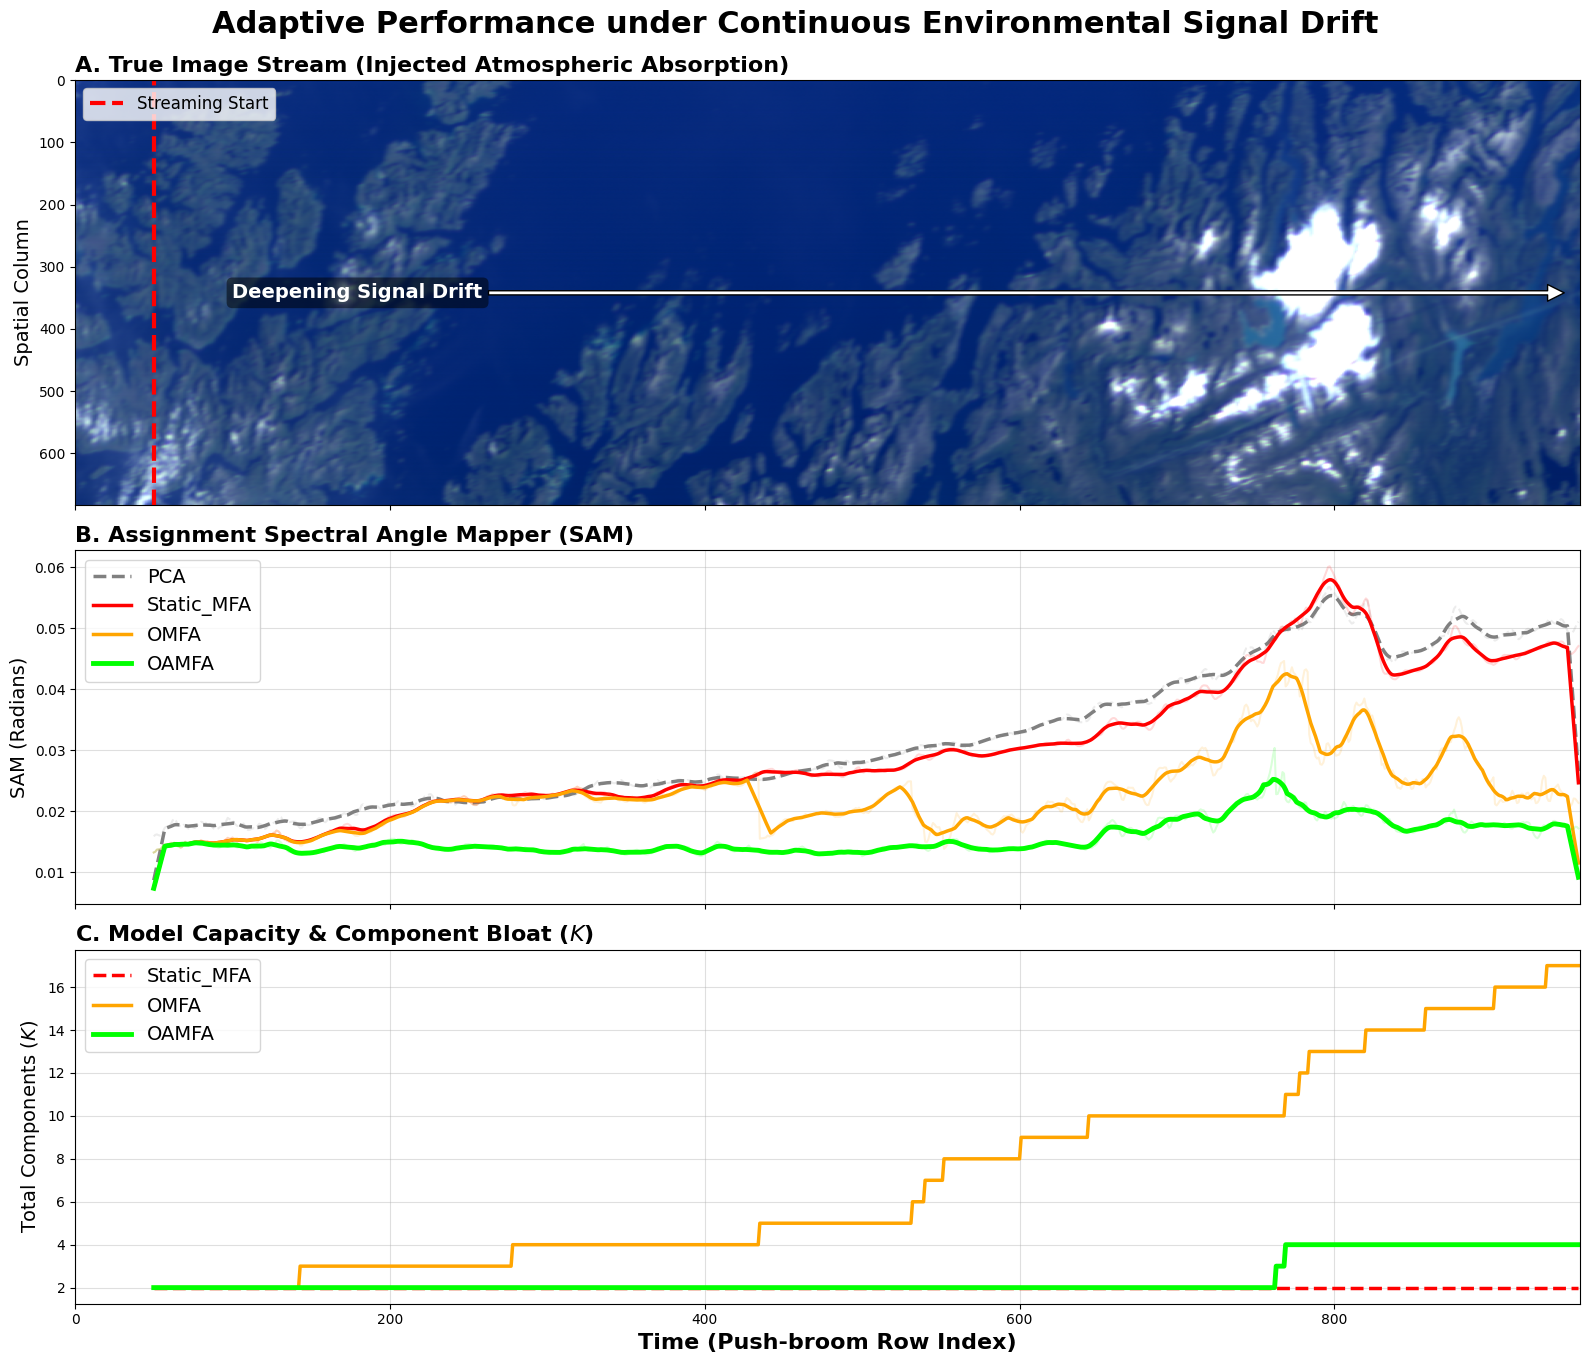

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("--- GENERATING FIGURE A: PERFORMANCE & BLOAT ---")

# --- 1. Helper Functions ---
def transpose_for_time_x(hsi_cube):
    """Swaps spatial dimensions so Time (Rows) is on the X-axis for RGB."""
    # Note: Assuming get_rgb() is defined in your environment
    return np.transpose(get_rgb(hsi_cube), (1, 0, 2))

def smooth_curve(y, window=15):
    """Calculates a moving average to smooth noisy row-by-row metrics."""
    box = np.ones(window) / window
    smoothed = np.convolve(y, box, mode='same')
    return smoothed

time_steps = np.arange(N_TRAIN_ROWS, N_TRAIN_ROWS + N_TEST_ROWS)

# --- 2. Figure Setup ---
# sharex=True locks the time axis across all plots!
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True, 
                         gridspec_kw={'height_ratios': [1.2, 1, 1]})

fig.suptitle("Adaptive Performance under Continuous Environmental Signal Drift", 
             fontsize=22, fontweight='bold', y=0.97)

# ==========================================
# PLOT A: True RGB Timeline & Drift Arrow
# ==========================================
# Using the drifted image we created in the previous cell
axes[0].imshow(transpose_for_time_x(img_drifted_full), aspect='auto')
axes[0].set_title(r"A. True Image Stream (Injected Atmospheric Absorption)", fontsize=16, fontweight='bold', loc='left')
axes[0].axvline(x=N_TRAIN_ROWS, color='red', linestyle='--', linewidth=3, label="Streaming Start")
axes[0].set_ylabel("Spatial Column", fontsize=14)
axes[0].legend(loc="upper left", fontsize=12)

# Add the arrow indicating the direction and deepening of the drift
axes[0].annotate('Deepening Signal Drift', 
                 xy=(H - 10, W // 2), xycoords='data',
                 xytext=(N_TRAIN_ROWS + 50, W // 2), textcoords='data',
                 arrowprops=dict(facecolor='white', edgecolor='black', width=3, headwidth=12),
                 fontsize=14, color='white', fontweight='bold', va='center',
                 bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="none", alpha=0.5))

# ==========================================
# PLOT B: Spectral Angle Mapper (SAM)
# ==========================================
axes[1].set_title(r"B. Assignment Spectral Angle Mapper (SAM)", fontsize=16, fontweight='bold', loc='left')

# Define the models, colors, and line styles
models = [
    ("PCA", "gray", "--"), 
    ("Static_MFA", "red", "-"), 
    ("OMFA", "orange", "-"), 
    ("OAMFA", "lime", "-")
]

for model_name, color, style in models:
    raw_sam = metrics[model_name]["sam"]
    smoothed_sam = smooth_curve(raw_sam)
    
    # Plot faint raw data
    axes[1].plot(time_steps, raw_sam, color=color, linestyle=style, alpha=0.15)
    
    # Plot bold smoothed data
    lw = 3.5 if model_name == "OAMFA" else 2.5
    axes[1].plot(time_steps, smoothed_sam, color=color, linestyle=style, linewidth=lw, label=model_name)

axes[1].set_ylabel("SAM (Radians)", fontsize=14)
axes[1].legend(loc="upper left", fontsize=14)
axes[1].grid(True, alpha=0.4)

# ==========================================
# PLOT C: Model Capacity (Component Bloat)
# ==========================================
axes[2].set_title(r"C. Model Capacity & Component Bloat ($K$)", fontsize=16, fontweight='bold', loc='left')

# We only track K for the MFA models
K_models = [
    ("Static_MFA", "red", "--"), 
    ("OMFA", "orange", "-"), 
    ("OAMFA", "lime", "-")
]

for model_name, color, style in K_models:
    # Assuming Static_MFA stays constant, OMFA shoots up, and OAMFA adapts gracefully
    raw_k = metrics[model_name]["K"]
    lw = 3.5 if model_name == "OAMFA" else 2.5
    axes[2].plot(time_steps, raw_k, color=color, linestyle=style, linewidth=lw, label=model_name)

axes[2].set_ylabel("Total Components ($K$)", fontsize=14)
axes[2].set_xlabel("Time (Push-broom Row Index)", fontsize=16, fontweight='bold')
axes[2].legend(loc="upper left", fontsize=14)
axes[2].grid(True, alpha=0.4)

# Limit the X-axis strictly to our data boundary
axes[2].set_xlim(0, H)

# Final Polish
plt.tight_layout()
fig.subplots_adjust(top=0.92) # Adjust to make sure suptitle isn't cut off
plt.show()

### Cluster asignment plot

Final OAMFA K value: 4


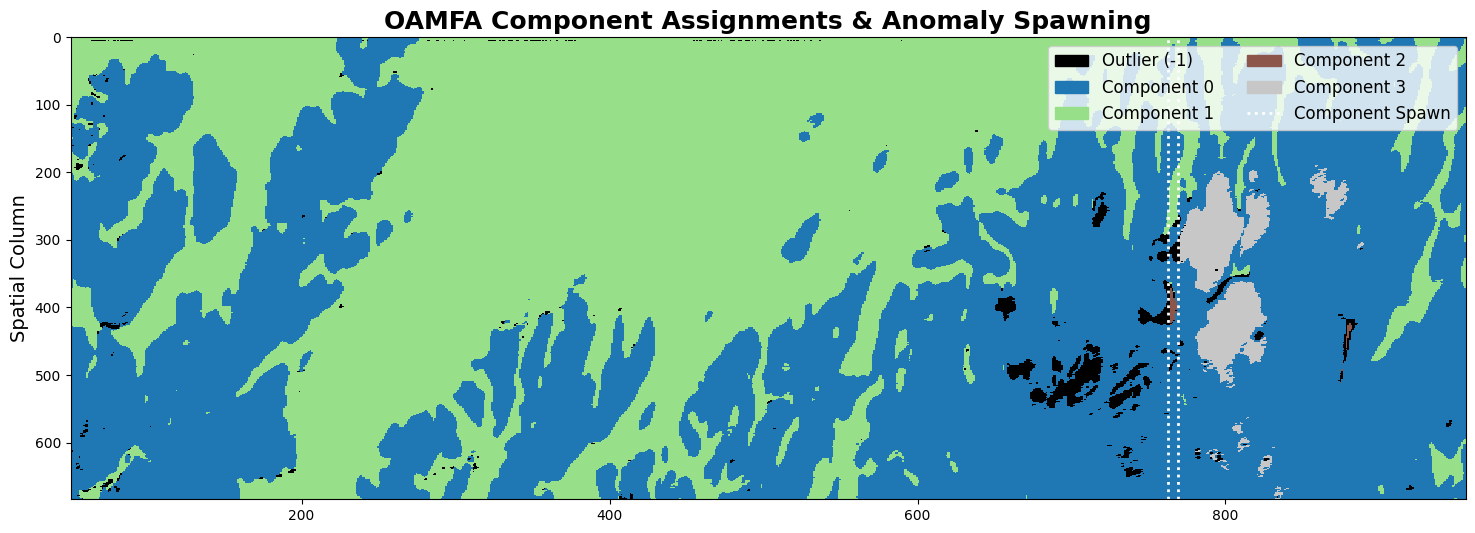

Final OMFA K value: 17


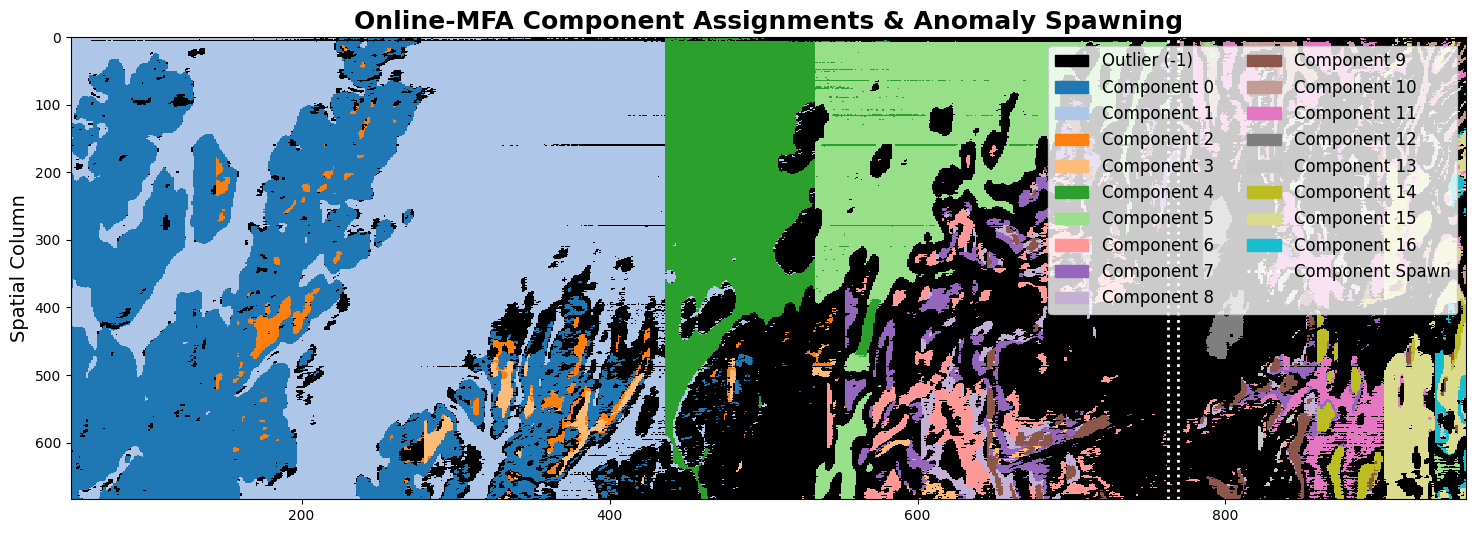

In [8]:
plot_configs = [
    {
        "title": r"OAMFA Component Assignments & Anomaly Spawning",
        "model_key": "OAMFA",
        "map_data": assignment_oamfa_map
    },
    {
        "title": r"Online-MFA Component Assignments & Anomaly Spawning",
        "model_key": "OMFA",
        "map_data": assignment_omfa_map
    }
]

# Loop through each configuration
for config in plot_configs:
    fig, axes = plt.subplots(1, 1, figsize=(18, 6), sharex=True)
    
    axes.set_title(config["title"], fontsize=18, fontweight='bold')
    
    cmap = copy.copy(plt.get_cmap("tab20"))
    cmap.set_under("black") # Force outliers (-1) to black
    
    # Extract the dynamic keys
    model_key = config["model_key"]
    final_k = metrics[model_key]["K"][-1]
    
    print(f"Final {model_key} K value: {final_k}")
    
    color_norm = Normalize(vmin=0, vmax=final_k) # Used to fetch exact colors for the legend
    
    im = axes.imshow(config["map_data"].T, aspect='auto', cmap=cmap, vmin=0, vmax=final_k,
                     extent=[N_TRAIN_ROWS, N_TRAIN_ROWS + h, w, 0], interpolation='nearest')
    
    # Draw the vertical spawn lines
    for sr in spawn_rows:
        axes.axvline(x=N_TRAIN_ROWS + sr, color='white', linestyle=':', linewidth=2)
    
    axes.set_ylabel("Spatial Column", fontsize=14)
    
    # --- Construct the Custom Legend ---
    legend_elements = []
    
    # 1. Add the Outlier category
    legend_elements.append(mpatches.Patch(color='black', label='Outlier (-1)'))
    
    # 2. Add dynamically generated Component categories
    for k in range(final_k):
        comp_color = cmap(color_norm(k))
        legend_elements.append(mpatches.Patch(color=comp_color, label=f'Component {k}'))
    
    # 3. Add the Spawn Line marker
    if len(spawn_rows) > 0:
        legend_elements.append(Line2D([0], [0], color='white', linestyle=':', linewidth=2, label='Component Spawn'))
    
    # Plot the legend (ncol=2 splits it into two columns to save space)
    axes.legend(handles=legend_elements, loc="upper right", fontsize=12, ncol=2)
    
    # Show the plot before moving to the next iteration (especially useful in Jupyter Notebooks)
    plt.show()

### Debugging plot

--- GENERATING MAHALANOBIS DISTANCE HEATMAP ---


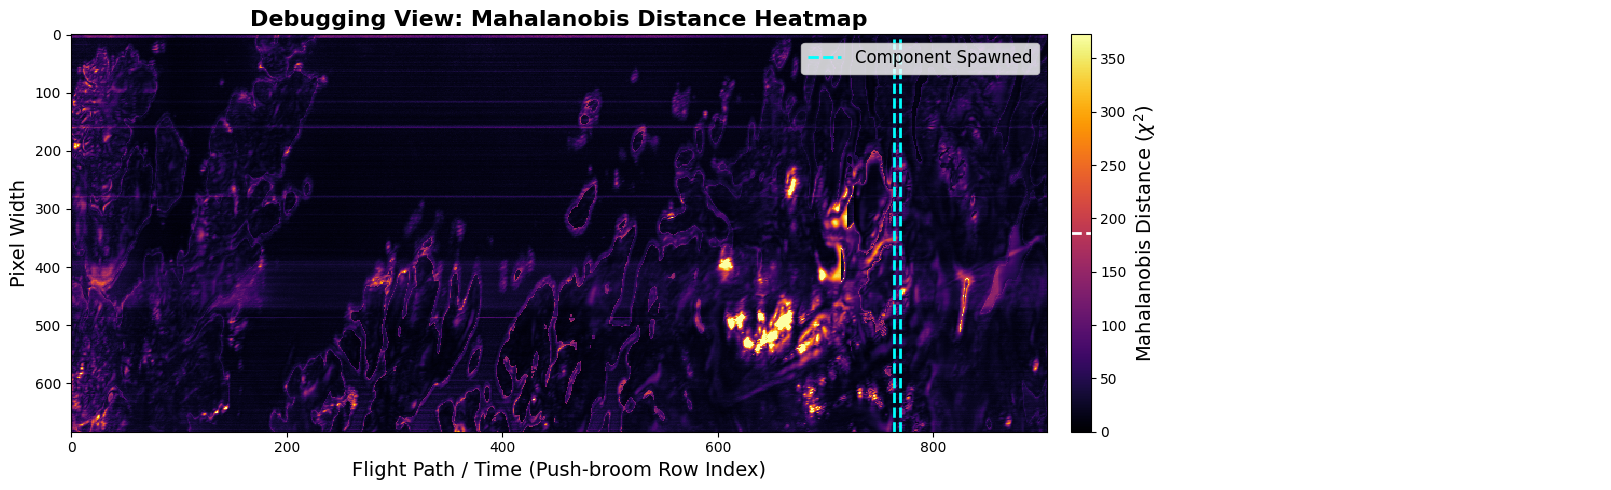

In [9]:
print("--- GENERATING MAHALANOBIS DISTANCE HEATMAP ---")

# --- 1. Preparation ---
# Fetch the threshold from the model to draw the "anomaly shoreline"
threshold = adaptive_online_MFA.chi2_threshold

# Cap the maximum visual value at 2x the threshold to match your style
vmax_heat = threshold * 2 

# --- 2. Figure Setup ---
fig, ax = plt.subplots(figsize=(16, 5))

# Transpose the map (.T) and apply the 'inferno' colormap
cax = ax.imshow(mahalanobis_map.T, aspect='auto', cmap='inferno', vmin=0, vmax=vmax_heat, interpolation='nearest')

# --- 3. Draw the Anomaly Shoreline (Contour) ---
x_range = np.arange(N_TRAIN_ROWS, N_TRAIN_ROWS + h)
y_range = np.arange(0, w)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

# --- 4. Colorbar Formatting ---
cbar = fig.colorbar(cax, ax=ax, pad=0.02)
cbar.set_label(r'Mahalanobis Distance ($\chi^2$)', fontsize=14)

# Draw a white line on the colorbar to mark the threshold limit
cbar.ax.axhline(threshold, color='white', linestyle='--', linewidth=2)
cbar.ax.text(vmax_heat * 0.05, threshold + (vmax_heat * 0.05), 'Anomaly Threshold', 
             color='white', fontsize=12, va='bottom')

# --- 5. Polish and Labels ---
ax.set_title("Debugging View: Mahalanobis Distance Heatmap", fontsize=16, fontweight='bold')
ax.set_xlabel("Flight Path / Time (Push-broom Row Index)", fontsize=14)
ax.set_ylabel("Pixel Width", fontsize=14)

# FIX: Loop through all spawn rows using your requested style
if 'spawn_rows' in locals() and len(spawn_rows) > 0:
    for i, s_row in enumerate(spawn_rows):
        lbl = "Component Spawned" if i == 0 else None
        ax.axvline(x=N_TRAIN_ROWS + s_row, color='cyan', linestyle='--', linewidth=2, label=lbl)
    ax.legend(loc="upper right", fontsize=12)

plt.tight_layout()
plt.show()

## \mu parameter-change 

--- GENERATING FIGURE C: PARAMETER EVOLUTION ---


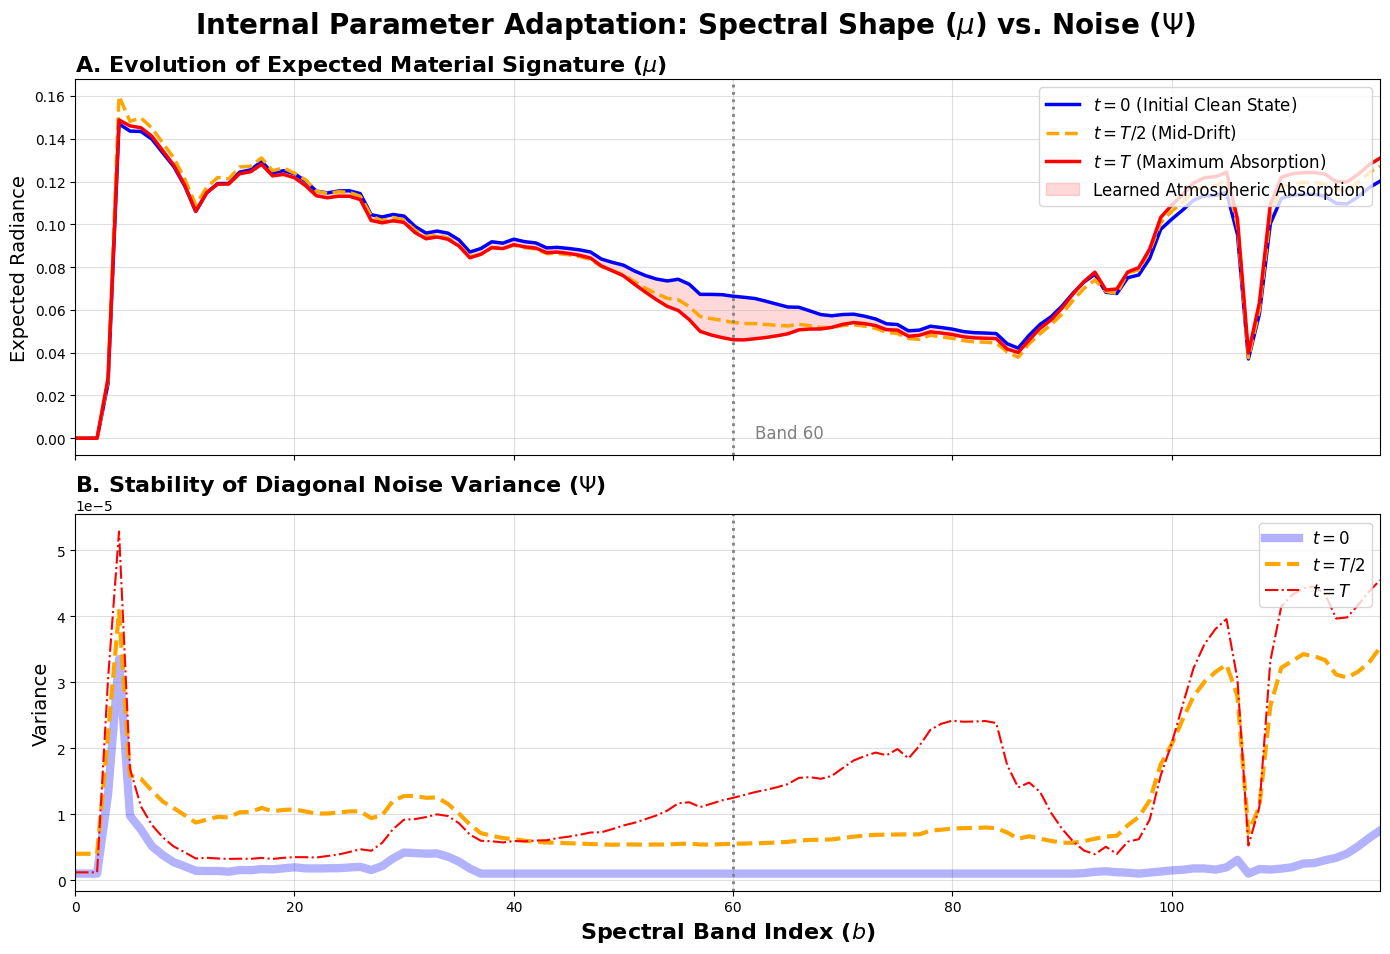

In [10]:
print("--- GENERATING FIGURE C: PARAMETER EVOLUTION ---")

# --- 1. Extract Snapshots ---
# Convert lists to 2D numpy arrays of shape (Time, Bands)
mu_matrix = np.array(oamfa_mu_history)
psi_matrix = np.exp(np.array(oamfa_psi_history)) # Convert from log-variance to linear variance

total_steps = len(mu_matrix)
t_start = 0
t_mid = total_steps // 2
t_end = total_steps - 1

bands = np.arange(mu_matrix.shape[1]) # [0, 1, ..., 119]
b_c = 60 # Center of your simulated absorption trough

# --- 2. Figure Setup ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle(r"Internal Parameter Adaptation: Spectral Shape ($\mu$) vs. Noise ($\Psi$)", 
             fontsize=20, fontweight='bold', y=0.95)

# ==========================================
# PLOT A: Expected Mean (Mu) Tracking the Drift
# ==========================================
axes[0].set_title(r"A. Evolution of Expected Material Signature ($\mu$)", fontsize=16, fontweight='bold', loc='left')

# Plot the three temporal snapshots
axes[0].plot(bands, mu_matrix[t_start], color='blue', linewidth=2.5, label=r"$t = 0$ (Initial Clean State)")
axes[0].plot(bands, mu_matrix[t_mid], color='orange', linewidth=2.5, linestyle='--', label=r"$t = T/2$ (Mid-Drift)")
axes[0].plot(bands, mu_matrix[t_end], color='red', linewidth=2.5, label=r"$t = T$ (Maximum Absorption)")

# VISUAL TRICK: Shade the area where the model learned the drift
axes[0].fill_between(bands, mu_matrix[t_start], mu_matrix[t_end], 
                     where=(mu_matrix[t_end] < mu_matrix[t_start]), 
                     color='red', alpha=0.15, label="Learned Atmospheric Absorption")

# Highlight the center of the absorption trough
axes[0].axvline(x=b_c, color='gray', linestyle=':', linewidth=2)
axes[0].text(b_c + 2, np.min(mu_matrix[t_end]), f"Band {b_c}", color='gray', fontsize=12)

axes[0].set_ylabel("Expected Radiance", fontsize=14)
axes[0].legend(loc="upper right", fontsize=12)
axes[0].grid(True, alpha=0.4)

# ==========================================
# PLOT B: Noise Matrix (Psi) Remaining Stable
# ==========================================
axes[1].set_title(r"B. Stability of Diagonal Noise Variance ($\Psi$)", fontsize=16, fontweight='bold', loc='left')

# Because the noise matrix should be completely stable, the lines will stack exactly on top of each other.
# We use progressively thicker and different dashed styles so the examiner can see all three!
axes[1].plot(bands, psi_matrix[t_start], color='blue', linewidth=6, alpha=0.3, label=r"$t = 0$")
axes[1].plot(bands, psi_matrix[t_mid], color='orange', linewidth=3, linestyle='--', label=r"$t = T/2$")
axes[1].plot(bands, psi_matrix[t_end], color='red', linewidth=1.5, linestyle='-.', label=r"$t = T$")

# Mark the center band here too for reference
axes[1].axvline(x=b_c, color='gray', linestyle=':', linewidth=2)

axes[1].set_ylabel("Variance", fontsize=14)
axes[1].set_xlabel("Spectral Band Index ($b$)", fontsize=16, fontweight='bold')
axes[1].legend(loc="upper right", fontsize=12)
axes[1].grid(True, alpha=0.4)

axes[1].set_xlim(0, len(bands)-1)

# Final Polish
plt.tight_layout()
fig.subplots_adjust(top=0.88)
plt.show()